## Importando bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import numpy as np
import time
import re
from pathlib import Path
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

## Funcões:

In [2]:
def gerar_kdeplots_normalizados_4fixos(
    dfs1, dfs2, dfs3, dfs4,
    labels1, labels2, labels3, labels4,
    nome_base,
    titulo_base,
    xlabel,
    ylabel,
    x_log=False,
    y_log=False,
    bw_adjust=1,
    x_min=None, x_max=None,
    y_min=None, y_max=None,
    broken_axis=False,
    break_ymin=None, break_ymax=None
):
    """
    Gera gráficos com 4 curvas KDE normalizadas sobrepostas, para 4 conjuntos fixos de DataFrames.

    Parâmetros:
    - dfs1, dfs2, dfs3, dfs4: Listas de DataFrames com colunas 'steps'.
    - labels1, labels2, labels3, labels4: Listas de rótulos para cada grupo.
    - nome_base: Prefixo para o nome do arquivo salvo.
    - titulo_base: Título do gráfico.
    - xlabel, ylabel: Rótulos dos eixos.
    - x_log, y_log: Escala logarítmica nos eixos.
    - bw_adjust: Suavização do KDE.
    - x_min, x_max, y_min, y_max: Limites dos eixos.
    - broken_axis: Se True, cria eixo y quebrado.
    - break_ymin, break_ymax: Limites intermediários para a quebra no eixo y.
    """
    
    grupos_dfs = [dfs1, dfs2, dfs3, dfs4]
    grupos_labels = [labels1, labels2, labels3, labels4]
    cores = ['blue', 'orange', 'green', 'red']

    for i in range(len(dfs1)):
        if broken_axis:
            fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 1]})
            fig.subplots_adjust(hspace=0.05)
            eixos = [ax1, ax2]
        else:
            fig, ax = plt.subplots(figsize=(8, 6))
            eixos = [ax]

        # Plotando os KDEs
        for dfs, labels, cor in zip(grupos_dfs, grupos_labels, cores):
            dados = dfs[i]['steps'].values
            label = labels[i]

            if x_log:
                dados = dados[dados > 0]

            for eixo in eixos:
                sns.kdeplot(
                    x=dados,
                    bw_adjust=bw_adjust,
                    color=cor,
                    label=label,
                    fill=False,
                    ax=eixo,
                    log_scale=x_log
                )

        # Ajustando escalas
        for eixo in eixos:
            if x_log:
                eixo.set_xscale('log')
            if y_log:
                eixo.set_yscale('log')
                # Forçar notação exponencial no eixo y
            eixo.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
            eixo.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
            eixo.set_xlabel(xlabel, fontsize=14)
            eixo.set_ylabel(ylabel, fontsize=14)

        # Ajuste dos limites e quebras
        if broken_axis:
            if y_max is not None and break_ymax is not None:
                ax1.set_ylim(break_ymax, y_max)
            if y_min is not None and break_ymin is not None:
                ax2.set_ylim(y_min, break_ymin)
            if x_min is not None and x_max is not None:
                ax1.set_xlim(x_min, x_max)
                ax2.set_xlim(x_min, x_max)

            # Marca visual da quebra
            ax1.spines['bottom'].set_visible(False)
            ax2.spines['top'].set_visible(False)
            ax1.xaxis.tick_top()
            ax1.tick_params(labeltop=False)
            ax2.xaxis.tick_bottom()

            d = .015  # tamanho dos slashes
            kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
            ax1.plot((-d, +d), (-d, +d), **kwargs)
            ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
            kwargs.update(transform=ax2.transAxes)
            ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
            ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            ax1.legend(fontsize=10)
            ax1.set_title(titulo_base, fontsize=16)
        else:
            if x_min is not None and x_max is not None:
                ax.set_xlim(x_min, x_max)
            if y_min is not None and y_max is not None:
                ax.set_ylim(y_min, y_max)
            ax.legend(fontsize=10)
            ax.set_title(titulo_base, fontsize=16)

        # Gera o nome do arquivo de forma segura
        label_safe_parts = [
            re.sub(r'_+', '_', re.sub(r'[^\w\_\.]', '_', labels[i])).strip('_')
            for labels in grupos_labels
        ]
        nome_arquivo = f"{nome_base}{'_vs_'.join(label_safe_parts)}.pdf"

        plt.tight_layout()
        plt.savefig(nome_arquivo)
        plt.show()

In [3]:
def gerar_kdeplots_normalizados_4fixos_SR(
    dfs1, dfs2, dfs3, dfs4, dfs5, dfs6,
    labels1, labels2, labels3, labels4, labels5, labels6,
    nome_base,
    titulo_base,
    xlabel,
    ylabel,
    x_log=False,
    y_log=False,
    bw_adjust=1,
    x_min=None, x_max=None,
    y_min=None, y_max=None,
    broken_axis=False,
    break_ymin=None, break_ymax=None
):
    """
    Gera gráficos com 4 curvas KDE normalizadas sobrepostas, para 4 conjuntos fixos de DataFrames.

    Parâmetros:
    - dfs1, dfs2, dfs3, dfs4: Listas de DataFrames com colunas 'steps'.
    - labels1, labels2, labels3, labels4: Listas de rótulos para cada grupo.
    - nome_base: Prefixo para o nome do arquivo salvo.
    - titulo_base: Título do gráfico.
    - xlabel, ylabel: Rótulos dos eixos.
    - x_log, y_log: Escala logarítmica nos eixos.
    - bw_adjust: Suavização do KDE.
    - x_min, x_max, y_min, y_max: Limites dos eixos.
    - broken_axis: Se True, cria eixo y quebrado.
    - break_ymin, break_ymax: Limites intermediários para a quebra no eixo y.
    """
    
    grupos_dfs = [dfs1, dfs2, dfs3, dfs4,dfs5,dfs6]
    grupos_labels = [labels1, labels2, labels3, labels4, labels5, labels6]
    cores = ['blue', 'orange', 'green', 'red','grey', 'black']

    for i in range(len(dfs1)):
        if broken_axis:
            fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 1]})
            fig.subplots_adjust(hspace=0.05)
            eixos = [ax1, ax2]
        else:
            fig, ax = plt.subplots(figsize=(8, 6))
            eixos = [ax]

        # Plotando os KDEs
        for dfs, labels, cor in zip(grupos_dfs, grupos_labels, cores):
            dados = dfs[i]['steps'].values
            label = labels[i]

            if x_log:
                dados = dados[dados > 0]

            for eixo in eixos:
                sns.kdeplot(
                    x=dados,
                    bw_adjust=bw_adjust,
                    color=cor,
                    label=label,
                    fill=False,
                    ax=eixo,
                    log_scale=x_log
                )

        # Ajustando escalas
        for eixo in eixos:
            if x_log:
                eixo.set_xscale('log')
            if y_log:
                eixo.set_yscale('log')
                # Forçar notação exponencial no eixo y
            eixo.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
            eixo.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
            eixo.set_xlabel(xlabel, fontsize=14)
            eixo.set_ylabel(ylabel, fontsize=14)

        # Ajuste dos limites e quebras
        if broken_axis:
            if y_max is not None and break_ymax is not None:
                ax1.set_ylim(break_ymax, y_max)
            if y_min is not None and break_ymin is not None:
                ax2.set_ylim(y_min, break_ymin)
            if x_min is not None and x_max is not None:
                ax1.set_xlim(x_min, x_max)
                ax2.set_xlim(x_min, x_max)

            # Marca visual da quebra
            ax1.spines['bottom'].set_visible(False)
            ax2.spines['top'].set_visible(False)
            ax1.xaxis.tick_top()
            ax1.tick_params(labeltop=False)
            ax2.xaxis.tick_bottom()

            d = .015  # tamanho dos slashes
            kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
            ax1.plot((-d, +d), (-d, +d), **kwargs)
            ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
            kwargs.update(transform=ax2.transAxes)
            ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
            ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            ax1.legend(fontsize=10)
            ax1.set_title(titulo_base, fontsize=16)
        else:
            if x_min is not None and x_max is not None:
                ax.set_xlim(x_min, x_max)
            if y_min is not None and y_max is not None:
                ax.set_ylim(y_min, y_max)
            ax.legend(fontsize=10)
            ax.set_title(titulo_base, fontsize=16)

        # Gera o nome do arquivo de forma segura
        label_safe_parts = [
            re.sub(r'_+', '_', re.sub(r'[^\w\_\.]', '_', labels[i])).strip('_')
            for labels in grupos_labels
        ]
        nome_arquivo = f"{nome_base}{'_vs_'.join(label_safe_parts)}.pdf"

        plt.tight_layout()
        plt.savefig(nome_arquivo)
        plt.show()

In [4]:
def gerar_kdeplots_normalizados_4fixos_n(
    dfs1, dfs2, dfs3, dfs4, dfs5, dfs6, dfs7, dfs8, dfs9,
    labels1, labels2, labels3, labels4, labels5, labels6, labels7, labels8, labels9, 
    nome_base,
    titulo_base,
    xlabel,
    ylabel,
    x_log=False,
    y_log=False,
    bw_adjust=1,
    x_min=None, x_max=None,
    y_min=None, y_max=None,
    broken_axis=False,
    break_ymin=None, break_ymax=None
):
    """
    Gera gráficos com 4 curvas KDE normalizadas sobrepostas, para 4 conjuntos fixos de DataFrames.

    Parâmetros:
    - dfs1, dfs2, dfs3, dfs4: Listas de DataFrames com colunas 'steps'.
    - labels1, labels2, labels3, labels4: Listas de rótulos para cada grupo.
    - nome_base: Prefixo para o nome do arquivo salvo.
    - titulo_base: Título do gráfico.
    - xlabel, ylabel: Rótulos dos eixos.
    - x_log, y_log: Escala logarítmica nos eixos.
    - bw_adjust: Suavização do KDE.
    - x_min, x_max, y_min, y_max: Limites dos eixos.
    - broken_axis: Se True, cria eixo y quebrado.
    - break_ymin, break_ymax: Limites intermediários para a quebra no eixo y.
    """
    
    grupos_dfs = [dfs1, dfs2, dfs3, dfs4,dfs5,dfs6, dfs7,dfs8, dfs9]
    grupos_labels = [labels1, labels2, labels3, labels4, labels5, labels6, labels7, labels8, labels9]
    cores = ['blue', 'orange', 'green', 'red','grey', 'black','olive', 'pink','navy', 'cyan']

    for i in range(len(dfs1)):
        if broken_axis:
            fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 1]})
            fig.subplots_adjust(hspace=0.05)
            eixos = [ax1, ax2]
        else:
            fig, ax = plt.subplots(figsize=(8, 6))
            eixos = [ax]

        # Plotando os KDEs
        for dfs, labels, cor in zip(grupos_dfs, grupos_labels, cores):
            dados = dfs[i]['steps'].values
            label = labels[i]

            if x_log:
                dados = dados[dados > 0]

            for eixo in eixos:
                sns.kdeplot(
                    x=dados,
                    bw_adjust=bw_adjust,
                    color=cor,
                    label=label,
                    fill=False,
                    ax=eixo,
                    log_scale=x_log
                )

        # Ajustando escalas
        for eixo in eixos:
            if x_log:
                eixo.set_xscale('log')
            if y_log:
                eixo.set_yscale('log')
                # Forçar notação exponencial no eixo y
            eixo.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
            eixo.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
            eixo.set_xlabel(xlabel, fontsize=14)
            eixo.set_ylabel(ylabel, fontsize=14)

        # Ajuste dos limites e quebras
        if broken_axis:
            if y_max is not None and break_ymax is not None:
                ax1.set_ylim(break_ymax, y_max)
            if y_min is not None and break_ymin is not None:
                ax2.set_ylim(y_min, break_ymin)
            if x_min is not None and x_max is not None:
                ax1.set_xlim(x_min, x_max)
                ax2.set_xlim(x_min, x_max)

            # Marca visual da quebra
            ax1.spines['bottom'].set_visible(False)
            ax2.spines['top'].set_visible(False)
            ax1.xaxis.tick_top()
            ax1.tick_params(labeltop=False)
            ax2.xaxis.tick_bottom()

            d = .015  # tamanho dos slashes
            kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
            ax1.plot((-d, +d), (-d, +d), **kwargs)
            ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
            kwargs.update(transform=ax2.transAxes)
            ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
            ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            ax1.legend(fontsize=10)
            ax1.set_title(titulo_base, fontsize=16)
        else:
            if x_min is not None and x_max is not None:
                ax.set_xlim(x_min, x_max)
            if y_min is not None and y_max is not None:
                ax.set_ylim(y_min, y_max)
            ax.legend(fontsize=10)
            ax.set_title(titulo_base, fontsize=16)

        # Gera o nome do arquivo de forma segura
        label_safe_parts = [
            re.sub(r'_+', '_', re.sub(r'[^\w\_\.]', '_', labels[i])).strip('_')
            for labels in grupos_labels
        ]
        nome_arquivo = f"{nome_base}{'_vs_'.join(label_safe_parts)}.pdf"

        plt.tight_layout()
        plt.savefig(nome_arquivo)
        plt.show()

## Dados

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [5]:
# O = 00
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_5"
df_NP01_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/"NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_5.dat", delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 2
df_NP01_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [6]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_10"
df_NP01_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [7]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [8]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [9]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 2s
df_NP01_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [10]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_50"
# O = 0
df_NP01_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# # O =6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 2
df_NP01_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [11]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [12]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_10"
#O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [13]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [14]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [15]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [16]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_50"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [17]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [18]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_10"
df_NP01_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [19]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')


# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')


### TCC = 0.05 e TCT = 0.05.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [20]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# # O = 21
df_NP01_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')


### TCC = 0.05 e TCT = 0.05.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [21]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_40"
df_NP01_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')


# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 2s
df_NP01_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [22]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_50"
# O = 0
df_NP01_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# # O =6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# # O = 2
df_NP01_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv (base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [23]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [24]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_10"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [25]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [26]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [27]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [28]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_50"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')

In [29]:
vai parar aqui

SyntaxError: invalid syntax (3198845648.py, line 1)

# Resultados

In [30]:
# Criar dados fictícios para os DataFrames
df1=[
        df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50, 
        df_NP1000_NH500_TCC_005_TCT_005_O_02_SR50,
        df_NP1000_NH500_TCC_005_TCT_005_O_03_SR50,
        df_NP1000_NH500_TCC_005_TCT_005_O_05_SR50, 
        df_NP1000_NH500_TCC_005_TCT_005_O_06_SR50,
        df_NP1000_NH500_TCC_005_TCT_005_O_11_SR50,
        df_NP1000_NH500_TCC_005_TCT_005_O_21_SR50, 
        df_NP1000_NH500_TCC_005_TCT_005_O_26_SR50,
        df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50
        ]
df2=[
        df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50, 
        df_NP1000_NH500_TCC_095_TCT_095_O_02_SR50,
        df_NP1000_NH500_TCC_095_TCT_095_O_03_SR50,
        df_NP1000_NH500_TCC_095_TCT_095_O_05_SR50, 
        df_NP1000_NH500_TCC_095_TCT_095_O_06_SR50,
        df_NP1000_NH500_TCC_095_TCT_095_O_11_SR50,
        df_NP1000_NH500_TCC_095_TCT_095_O_21_SR50, 
        df_NP1000_NH500_TCC_095_TCT_095_O_26_SR50,
        df_NP1000_NH500_TCC_095_TCT_095_O_51_SR50
        ]

# Lista de rótulos individuais para cada DataFrame
labels1 = [
    "$n_{R}^{R}$ = 0", "$n_{R}^{R}$ = 2", "$n_{R}^{R}$ = 3", "$n_{R}^{R}$ = 5", 
    "$n_{R}^{R}$ = 6", "$n_{R}^{R}$ = 11", "$n_{R}^{R}$ = 21" , "$n_{R}^{R}$ = 26", 
    "$n_{R}^{R}$ = 51"]
labels2 = [
    "$n_{D}^{D}$ = 0", "$n_{D}^{D}$ = 2", "$n_{D}^{D}$ = 3", "$n_{D}^{D}$ = 5", 
    "$n_{D}^{D}$ = 6", "$n_{D}^{D}$ = 11", "$n_{D}^{D}$ = 21" , "$n_{D}^{D}$ = 26", 
    "$n_{D}^{D}$ = 51"]

# Chamando a função para gerar os histogramas normalizados
gerar_histogramas_normalizados(
    dfs1=df1,
    dfs2=df2,
    labels1=labels1,
    labels2=labels2,
    nome_base="NP1000_NH500_SR50_TCC",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",   
    xlabel="Steps",
    ylabel="Frequency",
    bins=30,
    x_log=False,
    y_log=False,
    x_min=0, 
    x_max=500, 
    y_min=10e-5, 
    y_max=30e-3
)

NameError: name 'gerar_histogramas_normalizados' is not defined

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[
        df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05, 
        df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05, 
        df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05, 
        df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05
        ]
df2=[
        df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05, 
        df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05, 
        df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05, 
        df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05
        ]

# Lista de rótulos individuais para cada DataFrame
labels1 = [
    "$n_{D}^{R}$ = 0", "$n_{D}^{R}$ = 2", "$n_{D}^{R}$ = 3", "$n_{D}^{R}$ = 5", 
    "$n_{D}^{R}$ = 6", "$n_{D}^{R}$ = 11", "$n_{D}^{R}$ = 21" , "$n_{D}^{R}$ = 26", 
    "$n_{D}^{R}$ = 51"]
labels2 = [
    "$n_{R}^{D}$ = 0", "$n_{R}^{D}$ = 2", "$n_{R}^{D}$ = 3", "$n_{R}^{D}$ = 5", 
    "$n_{R}^{D}$ = 6", "$n_{R}^{D}$ = 11", "$n_{R}^{D}$ = 21" , "$n_{R}^{D}$ = 26", 
    "$n_{R}^{D}$ = 51"]

# Chamando a função para gerar os histogramas normalizados
gerar_histogramas_normalizados(
    dfs1=df1,
    dfs2=df2,
    labels1=labels1,
    labels2=labels2,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",   
    xlabel="Steps",
    ylabel="Frequency",
    bins=30,
    x_log=False,
    y_log=False,
    x_min=0, 
    x_max=500, 
    y_min=10e-5, 
    y_max=30e-3
)

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[
        df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30, 
        df_NP1000_NH500_TCC_095_TCT_005_O_02_SR30,
        df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30,
        df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30, 
        df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30,
        df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30,
        df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30, 
        df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30,
        df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30
        ]
df2=[
        df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30, 
        df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30,
        df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30,
        df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30, 
        df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30,
        df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30,
        df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30, 
        df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30,
        df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30
        ]

# Lista de rótulos individuais para cada DataFrame
labels1 = [
    "$n_{D}^{R}$ = 0", "$n_{D}^{R}$ = 2", "$n_{D}^{R}$ = 3", "$n_{D}^{R}$ = 5", 
    "$n_{D}^{R}$ = 6", "$n_{D}^{R}$ = 11", "$n_{D}^{R}$ = 21" , "$n_{D}^{R}$ = 26", 
    "$n_{D}^{R}$ = 51"]
labels2 = [
    "$n_{R}^{D}$ = 0", "$n_{R}^{D}$ = 2", "$n_{R}^{D}$ = 3", "$n_{R}^{D}$ = 5", 
    "$n_{R}^{D}$ = 6", "$n_{R}^{D}$ = 11", "$n_{R}^{D}$ = 21" , "$n_{R}^{D}$ = 26", 
    "$n_{R}^{D}$ = 51"]

# Chamando a função para gerar os histogramas normalizados
gerar_histogramas_normalizados(
    dfs1=df1,
    dfs2=df2,
    labels1=labels1,
    labels2=labels2,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",   
    xlabel="Steps",
    ylabel="Frequency",
    bins=30,
    x_log=False,
    y_log=False,
    x_min=0, 
    x_max=500, 
    y_min=10e-5, 
    y_max=30e-3
)

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[
        df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05, 
        df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05, 
        df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05, 
        df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05,
        df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05
        ]
df2=[
        df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05, 
        df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05, 
        df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05, 
        df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05,
        df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05
        ]

# Lista de rótulos individuais para cada DataFrame
labels1 = [
    "$n_{R}^{D}$ = 0", "$n_{R}^{D}$ = 2", "$n_{R}^{D}$ = 3", "$n_{R}^{D}$ = 5", 
    "$n_{R}^{D}$ = 6", "$n_{R}^{D}$ = 11", "$n_{R}^{D}$ = 21" , "$n_{R}^{D}$ = 26", 
    "$n_{R}^{D}$ = 51"]
labels2 = [
    "$n_{D}^{R}$ = 0", "$n_{D}^{R}$ = 2", "$n_{D}^{R}$ = 3", "$n_{D}^{R}$ = 5", 
    "$n_{D}^{R}$ = 6", "$n_{D}^{R}$ = 11", "$n_{D}^{R}$ = 21" , "$n_{D}^{R}$ = 26", 
    "$n_{D}^{R}$ = 51"]

# Chamando a função para gerar os histogramas normalizados
gerar_histogramas_normalizados(
    dfs1=df1,
    dfs2=df2,
    labels1=labels1,
    labels2=labels2,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",   
    xlabel="Steps",
    ylabel="Frequency",
    bins=30,
    x_log=False,
    y_log=False,
    x_min=0, 
    x_max=500, 
    y_min=10e-5, 
    y_max=30e-3
)

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[
        df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10, 
        df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10,
        df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10,
        df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10, 
        df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10,
        df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10,
        df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10, 
        df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10,
        df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10
        ]
df2=[
        df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10, 
        df_NP1000_NH500_TCC_095_TCT_005_O_02_SR10,
        df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10,
        df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10, 
        df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10,
        df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10,
        df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10, 
        df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10,
        df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10
        ]

# Lista de rótulos individuais para cada DataFrame
labels1 = [
    "$n_{R}^{D}$ = 0", "$n_{R}^{D}$ = 2", "$n_{R}^{D}$ = 3", "$n_{R}^{D}$ = 5", 
    "$n_{R}^{D}$ = 6", "$n_{R}^{D}$ = 11", "$n_{R}^{D}$ = 21" , "$n_{R}^{D}$ = 26", 
    "$n_{R}^{D}$ = 51"]
labels2 = [
    "$n_{D}^{R}$ = 0", "$n_{D}^{R}$ = 2", "$n_{D}^{R}$ = 3", "$n_{D}^{R}$ = 5", 
    "$n_{D}^{R}$ = 6", "$n_{D}^{R}$ = 11", "$n_{D}^{R}$ = 21" , "$n_{D}^{R}$ = 26", 
    "$n_{D}^{R}$ = 51"]

# Chamando a função para gerar os histogramas normalizados
gerar_histogramas_normalizados(
    dfs1=df1,
    dfs2=df2,
    labels1=labels1,
    labels2=labels2,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",   
    xlabel="Steps",
    ylabel="Frequency",
    bins=30,
    x_log=False,
    y_log=False,
    x_min=0, 
    x_max=500, 
    y_min=10e-5, 
    y_max=30e-3
)

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[
        df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20, 
        df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20,
        df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20,
        df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20, 
        df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20,
        df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20,
        df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20, 
        df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20,
        df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20
        ]
df2=[
        df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20, 
        df_NP1000_NH500_TCC_095_TCT_005_O_02_SR20,
        df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20,
        df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20, 
        df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20,
        df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20,
        df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20, 
        df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20,
        df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20
        ]

# Lista de rótulos individuais para cada DataFrame
labels1 = [
    "$n_{R}^{D}$ = 0", "$n_{R}^{D}$ = 2", "$n_{R}^{D}$ = 3", "$n_{R}^{D}$ = 5", 
    "$n_{R}^{D}$ = 6", "$n_{R}^{D}$ = 11", "$n_{R}^{D}$ = 21" , "$n_{R}^{D}$ = 26", 
    "$n_{R}^{D}$ = 51"]
labels2 = [
    "$n_{D}^{R}$ = 0", "$n_{D}^{R}$ = 2", "$n_{D}^{R}$ = 3", "$n_{D}^{R}$ = 5", 
    "$n_{D}^{R}$ = 6", "$n_{D}^{R}$ = 11", "$n_{D}^{R}$ = 21" , "$n_{D}^{R}$ = 26", 
    "$n_{D}^{R}$ = 51"]

# Chamando a função para gerar os histogramas normalizados
gerar_histogramas_normalizados(
    dfs1=df1,
    dfs2=df2,
    labels1=labels1,
    labels2=labels2,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",   
    xlabel="Steps",
    ylabel="Frequency",
    bins=30,
    x_log=False,
    y_log=False,
    x_min=0, 
    x_max=500, 
    y_min=10e-5, 
    y_max=30e-3
)

## Histogramas.
## TCC = 0.05 TCT = 0.05 e TCC = 0.95 TCT = 0.05
## TCC = 0.05 TCT = 0.95 e TCC = 0.95 TCT = 0.95
## Variando o regime da dinamica.

### SR = 5, n = 0, NH = 500, NP = 100.

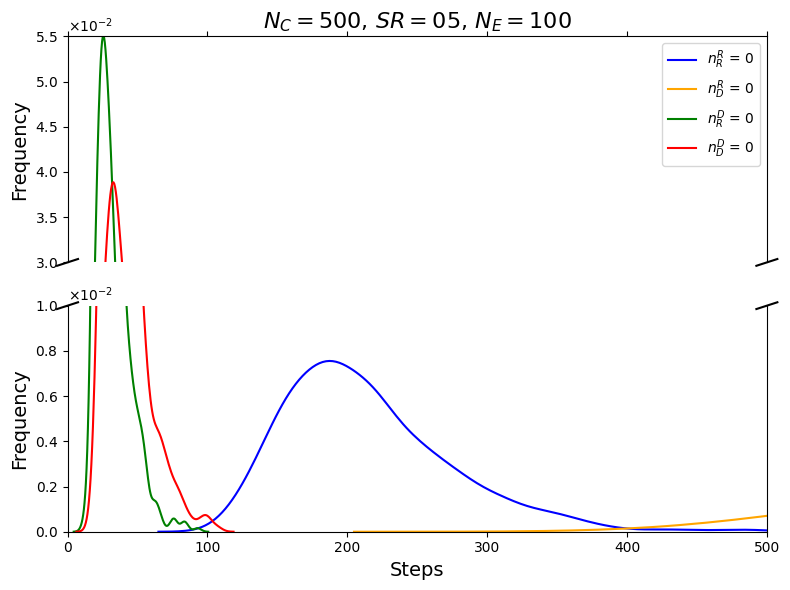

In [31]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR05]
# Lista de rótulos individuais para cada DataFrame
labels1 = [
    "$n_{R}^{R}$ = 0"]
labels2 = [
    "$n_{D}^{R}$ = 0"]
labels3 = [
    "$n_{R}^{D}$ = 0"]
labels4 = [
    "$n_{D}^{D}$ = 0"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1, dfs2=df2, dfs3=df3, dfs4=df4,
    labels1=labels1, labels2=labels2, labels3=labels3, labels4=labels4,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1e-2,   
    break_ymax=3e-2)

### SR = 5, n = 2, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR05]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=3e-2)

### SR = 5, n = 3, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR05]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.1e-2,   
    break_ymax=3e-2)

### SR = 5, n = 5, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR05]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3e-2)

### SR = 5, n = 6, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR05]
# Lista de rótulos individuais para cada DataFrame
labels1 = [
    "$n_{R}^{R}$ = 6"]
labels2 = [
    "$n_{D}^{R}$ = 6"]
labels3 = [
    "$n_{R}^{D}$ = 6"]
labels4 = [
    "$n_{D}^{D}$ = 6"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.1e-2,   
    break_ymax=3e-2)

### SR = 5, n = 11, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR05]
# Lista de rótulos individuais para cada DataFrame
labels1 = [
    "$n_{R}^{R}$ = 11"]
labels2 = [
    "$n_{D}^{R}$ = 11"]
labels3 = [
    "$n_{R}^{D}$ = 11"]
labels4 = [
    "$n_{D}^{D}$ = 11"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.1e-2,   
    break_ymax=3e-2)

### SR = 5, n = 21, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR05]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3e-2)

### SR = 5, n = 26, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR05]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=6.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=3e-2)

### SR = 5, n = 51, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR05]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4e-2)


### SR = 10, n = 0, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR10]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.0e-2,
    broken_axis=True,
    break_ymin=1.0e-2,   
    break_ymax=2e-2)

### SR = 10, n = 2, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR10]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.20e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 3, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR10]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)


### SR = 10, n = 5, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR10]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 6, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR10]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 5"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 11, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR10]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 21, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR10]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3.0e-2)

### SR = 10, n = 26, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR10]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=4.0e-2)

### SR = 10, n = 51, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR10]
# Lista de rótulos individuais para cada DataFrame
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]

gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=9.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=5.5e-2)

### SR = 20, n = 0, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR20]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 2, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR20]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 3, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR20]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 5, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR20]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 6, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR20]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 11, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR20]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 21, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR20]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 26, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR20]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 51, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR20]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]

# Chamando a função para gerar os histogramas normalizados
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=9.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 30, n = 0, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR30]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 2, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR30]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 3, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR30]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 5, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR30]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 6, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR30]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 11, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR30]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 21, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR30]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 26, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR30]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.5e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 51, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR30]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=10.2e-2,
    broken_axis=True,
    break_ymin=2.3e-2,   
    break_ymax=4.0e-2)

### SR = 40, n = 0, NH = 500, NP = 100.

In [ ]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR40]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 40, n = 2, NH = 500, NP = 100.

In [ ]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR40]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 3, NH = 500, NP = 100.

In [ ]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR40]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 5, NH = 500, NP = 100.

In [ ]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR40]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 6, NH = 500, NP = 100.

In [ ]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR40]
labels1 = ["$n_{R}^{R}$ = 06"]
labels2 = ["$n_{D}^{R}$ = 06"]
labels3 = ["$n_{R}^{D}$ = 06"]
labels4 = ["$n_{D}^{D}$ = 06"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 11, NH = 500, NP = 100.

In [ ]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR40]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 21, NH = 500, NP = 100.

In [ ]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR40]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 26, NH = 500, NP = 100.

In [ ]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR40]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.5e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 51, NH = 500, NP = 100.

In [ ]:
df1=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR40]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=10.5e-2,
    broken_axis=True,
    break_ymin=1.9e-2,   
    break_ymax=2.8e-2)

### SR = 50, n = 0, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR50]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 2, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR50]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 3, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR50]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 5, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR50]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 6, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR50]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=1.8e-2)


### SR = 50, n = 11, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR50]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 21, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR50]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 26, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR50]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 51, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR50]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=10.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 5, n = 0, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR05]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1e-2,   
    break_ymax=3e-2)

### SR = 5, n = 2, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR05]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=3e-2)


### SR = 5, n = 3, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR05]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.1e-2,   
    break_ymax=3e-2)

### SR = 5, n = 5, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR05]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3e-2)

### SR = 5, n = 6, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR05]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3e-2)

### SR = 5, n = 11, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR05]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.1e-2,   
    break_ymax=3e-2)

### SR = 5, n = 21, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR05]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3e-2)

### SR = 5, n = 26, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR05]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=6.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=3e-2)

### SR = 5, n = 51, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR05]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4e-2)

### SR = 10, n = 0, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR10]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.0e-2,
    broken_axis=True,
    break_ymin=1.0e-2,   
    break_ymax=2e-2)


### SR = 10, n = 2, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR10]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 3, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR10]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=6.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 5, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR10]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 6, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR10]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 11, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR10]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 21, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR10]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3.0e-2)

### SR = 10, n = 26, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR10]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=4.0e-2)

### SR = 10, n = 51, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR10]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=9.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=5.5e-2)

### SR = 20, n = 0, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR20]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 2, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR20]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 3, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR20]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 5, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR20]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 6, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR20]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 11, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR20]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 21, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR20]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 26, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR20]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 51, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR20]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=9.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 30, n = 0, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR30]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=6.0e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=4.0e-2)

### SR = 30, n = 2, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR30]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 3, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR30]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 5, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR30]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 6, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR30]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 11, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR30]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 21, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR30]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 26, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR30]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.5e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 51, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR30]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=10.2e-2,
    broken_axis=True,
    break_ymin=2.3e-2,   
    break_ymax=4.0e-2)

### SR = 40, n = 0, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR40]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 40, n = 2, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR40]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 3, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR40]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 5, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR40]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 6, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR40]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 11, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR40]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 21, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR40]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 26, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR40]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.5e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 51, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR40]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=10.5e-2,
    broken_axis=True,
    break_ymin=1.9e-2,   
    break_ymax=2.8e-2)

### SR = 50, n = 0, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR50]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 2, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR50]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 3, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR50]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 5, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR50]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 6, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR50]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 11, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR50]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 21, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR50]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 26, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR50]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 51, NH = 500, NP = 500.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR50]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=10.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 5, n = 0, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR05]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1e-2,   
    break_ymax=3e-2)

### SR = 5, n = 2, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR05]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=3e-2)

### SR = 5, n = 3, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR05]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 5, n = 5, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR05]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3e-2)

### SR = 5, n = 6, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR05]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3e-2)

### SR = 5, n = 11, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR05]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.1e-2,   
    break_ymax=3e-2)

### SR = 5, n = 21, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR05]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=5.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3e-2)

### SR = 5, n = 26, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR05]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=6.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=3e-2)

### SR = 5, n = 51, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR05]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4e-2)

### SR = 10, n = 0, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR10]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.0e-2,
    broken_axis=True,
    break_ymin=1.0e-2,   
    break_ymax=2e-2)

### SR = 10, n = 2, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR10]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 3, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR10]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 5, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR10]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 6, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR10]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 11, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR10]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 10, n = 21, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR10]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=3.0e-2)

### SR = 10, n = 26, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR10]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=4.0e-2)

### SR = 10, n = 51, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR10]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=9.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=5.5e-2)

### SR = 20, n = 0, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR20]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=6.0e-2,
    broken_axis=True,
    break_ymin=1.1e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 2, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR20]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 3, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR20]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 5, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR20]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.5e-2)

### SR = 20, n = 6, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR20]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 11, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR20]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 21, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR20]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 26, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR20]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=2.0e-2)

### SR = 20, n = 51, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR20]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=9.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 30, n = 0, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR30]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=9.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 30, n = 2, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR30]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 3, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR30]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 5, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR30]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 6, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR30]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 11, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR30]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 21, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR30]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.5e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 26, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR30]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.5e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=2.0e-2)

### SR = 30, n = 51, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR30]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=10.2e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 40, n = 0, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR40]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=2.0e-2)

### SR = 40, n = 2, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR40]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 3, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR40]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 5, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR40]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 6, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR40]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 11, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR40]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 21, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR40]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.5e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 26, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR40]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.5e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=2.5e-2)

### SR = 40, n = 51, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR40]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=10.5e-2,
    broken_axis=True,
    break_ymin=1.9e-2,   
    break_ymax=2.8e-2)

### SR = 50, n = 0, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50]
labels1 = ["$n_{R}^{R}$ = 0"]
labels2 = ["$n_{D}^{R}$ = 0"]
labels3 = ["$n_{R}^{D}$ = 0"]
labels4 = ["$n_{D}^{D}$ = 0"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 2, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR50]
labels1 = ["$n_{R}^{R}$ = 2"]
labels2 = ["$n_{D}^{R}$ = 2"]
labels3 = ["$n_{R}^{D}$ = 2"]
labels4 = ["$n_{D}^{D}$ = 2"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 3, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR50]
labels1 = ["$n_{R}^{R}$ = 3"]
labels2 = ["$n_{D}^{R}$ = 3"]
labels3 = ["$n_{R}^{D}$ = 3"]
labels4 = ["$n_{D}^{D}$ = 3"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=7.5e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 5, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR50]
labels1 = ["$n_{R}^{R}$ = 5"]
labels2 = ["$n_{D}^{R}$ = 5"]
labels3 = ["$n_{R}^{D}$ = 5"]
labels4 = ["$n_{D}^{D}$ = 5"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.2e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 6, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR50]
labels1 = ["$n_{R}^{R}$ = 6"]
labels2 = ["$n_{D}^{R}$ = 6"]
labels3 = ["$n_{R}^{D}$ = 6"]
labels4 = ["$n_{D}^{D}$ = 6"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 11, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR50]
labels1 = ["$n_{R}^{R}$ = 11"]
labels2 = ["$n_{D}^{R}$ = 11"]
labels3 = ["$n_{R}^{D}$ = 11"]
labels4 = ["$n_{D}^{D}$ = 11"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 21, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR50]
labels1 = ["$n_{R}^{R}$ = 21"]
labels2 = ["$n_{D}^{R}$ = 21"]
labels3 = ["$n_{R}^{D}$ = 21"]
labels4 = ["$n_{D}^{D}$ = 21"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.3e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 26, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR50]
labels1 = ["$n_{R}^{R}$ = 26"]
labels2 = ["$n_{D}^{R}$ = 26"]
labels3 = ["$n_{R}^{D}$ = 26"]
labels4 = ["$n_{D}^{D}$ = 26"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=8.0e-2,
    broken_axis=True,
    break_ymin=1.4e-2,   
    break_ymax=1.8e-2)

### SR = 50, n = 51, NH = 500, NP = 1000.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR50]
labels1 = ["$n_{R}^{R}$ = 51"]
labels2 = ["$n_{D}^{R}$ = 51"]
labels3 = ["$n_{R}^{D}$ = 51"]
labels4 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=10.5e-2,
    broken_axis=True,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

In [ ]:
para aqui

## Histogramas.
## TCC = 0.05 TCT = 0.05 
## Variando o $n$.

### SR = 5, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR05]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR05]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR05]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR05]
df7=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR05]
df8=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR05]
df9=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR05]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    dfs5=df5,
    dfs6=df6,
    dfs7=df7,
    dfs8=df8,
    dfs9=df9,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    labels5=labels5,
    labels6=labels6,
    labels7=labels7,
    labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 5$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=12e-3,
    broken_axis=False,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR10]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR10]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR10]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR10]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR10]
df7=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR10]
df8=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR10]
df9=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR10]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    dfs5=df5,
    dfs6=df6,
    dfs7=df7,
    dfs8=df8,
    dfs9=df9,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    labels5=labels5,
    labels6=labels6,
    labels7=labels7,
    labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR10]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR10]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR10]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR10]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR10]
df7=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR10]
df8=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR10]
df9=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR10]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,
    dfs2=df2,
    dfs3=df3,
    dfs4=df4,
    dfs5=df5,
    dfs6=df6,
    dfs7=df7,
    dfs8=df8,
    dfs9=df9,
    labels1=labels1,
    labels2=labels2,
    labels3=labels3,
    labels4=labels4,
    labels5=labels5,
    labels6=labels6,
    labels7=labels7,
    labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps",
    ylabel="Frequency",
    x_log=False,
    y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR30]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR30]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR30]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR30]
df7=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR30]
df8=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR30]
df9=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR30]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=20e-3,
    broken_axis=False,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR40]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR40]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR40]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR40]
df7=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR40]
df8=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR40]
df9=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR40]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=20e-3,
    broken_axis=False,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 100.

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR50]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR50]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR50]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR50]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR50]
df7=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR50]
df8=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR50]
df9=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR50]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=20e-3,
    broken_axis=False,
    break_ymin=2.0e-2,   
    break_ymax=4.0e-2)

### SR = 05, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR05]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR05]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR05]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR05]
df7=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR05]
df8=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR05]
df9=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR05]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=12e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR10]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR10]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR10]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR10]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR10]
df7=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR10]
df8=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR10]
df9=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR10]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR20]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR20]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR20]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR20]
df7=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR20]
df8=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR20]
df9=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR20]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR30]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR30]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR30]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR30]
df7=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR30]
df8=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR30]
df9=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR30]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR40]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR40]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR40]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR40]
df7=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR40]
df8=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR40]
df9=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR40]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR50]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR50]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR50]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR50]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR50]
df7=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR50]
df8=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR50]
df9=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR50]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 05, NH = 1000, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR05]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR05]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR05]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR05]
df7=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR05]
df8=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR05]
df9=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR05]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=12e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 1000, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR10]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR10]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR10]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR10]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR10]
df7=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR10]
df8=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR10]
df9=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR10]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR20]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR20]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR20]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR20]
df7=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR20]
df8=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR20]
df9=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR20]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR30]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR30]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR30]
df7=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR30]
df8=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR30]
df9=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR30]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR40]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR40]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR40]
df7=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR40]
df8=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR40]
df9=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR40]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=18e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR50]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR50]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR50]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR50]
df7=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR50]
df8=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR50]
df9=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50]

labels1 = ["$n_{R}^{R}$ = 00"]
labels2 = ["$n_{R}^{R}$ = 02"]
labels3 = ["$n_{R}^{R}$ = 03"]
labels4 = ["$n_{R}^{R}$ = 05"]
labels5 = ["$n_{R}^{R}$ = 06"]
labels6 = ["$n_{R}^{R}$ = 11"]
labels7 = ["$n_{R}^{R}$ = 21"]
labels8 = ["$n_{R}^{R}$ = 26"]
labels9 = ["$n_{R}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=500,
    y_min=0, y_max=15e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

## Histogramas.
## TCC = 0.05 TCT = 0.95 
## Variando o $n$.

### SR = 05, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR05]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR05]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR05]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR05]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR05]
df7=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR05]
df8=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR05]
df9=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR05]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=70e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR10]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR10]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR10]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR10]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR10]
df7=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR10]
df8=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR10]
df9=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR10]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=90e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR20]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR20]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR20]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR20]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR20]
df7=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR20]
df8=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR20]
df9=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR20]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=50,
    y_min=0, y_max=95e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR30]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR30]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR30]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR30]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR30]
df7=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR30]
df8=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR30]
df9=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR30]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=110e-3,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR40]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR40]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR40]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR40]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR40]
df7=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR40]
df8=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR40]
df9=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR40]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=10e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR50]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR50]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR50]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR50]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR50]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR50]
df7=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR50]
df8=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR50]
df9=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR50]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=10e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 05, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR05]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR05]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR05]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR05]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR05]
df7=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR05]
df8=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR05]
df9=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR05]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=06e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR10]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR10]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR10]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR10]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR10]
df7=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR10]
df8=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR10]
df9=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR10]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=8e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR20]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR20]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR20]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR20]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR20]
df7=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR20]
df8=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR20]
df9=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR20]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=8e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR30]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR30]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR30]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR30]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR30]
df7=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR30]
df8=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR30]
df9=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR30]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=8e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR40]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR40]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR40]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR40]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR40]
df7=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR40]
df8=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR40]
df9=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR40]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=8e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR50]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR50]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR50]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR50]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR50]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR50]
df7=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR50]
df8=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR50]
df9=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR50]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 05, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05]
df7=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05]
df8=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05]
df9=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=6e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10]
df7=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10]
df8=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10]
df9=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=8e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20]
df7=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20]
df8=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20]
df9=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30]
df7=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30]
df8=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30]
df9=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR40]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR40]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR40]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR40]
df7=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR40]
df8=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR40]
df9=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR50]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR50]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR50]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR50]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR50]
df7=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR50]
df8=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR50]
df9=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50]

labels1 = ["$n_{R}^{D}$ = 00"]
labels2 = ["$n_{R}^{D}$ = 02"]
labels3 = ["$n_{R}^{D}$ = 03"]
labels4 = ["$n_{R}^{D}$ = 05"]
labels5 = ["$n_{R}^{D}$ = 06"]
labels6 = ["$n_{R}^{D}$ = 11"]
labels7 = ["$n_{R}^{D}$ = 21"]
labels8 = ["$n_{R}^{D}$ = 26"]
labels9 = ["$n_{R}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=8e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

## Histogramas.
## TCC = 0.95 TCT = 0.05 
## Variando o $n$.

### SR = 05, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR05]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR05]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR05]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR05]
df7=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR05]
df8=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR05]
df9=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR05]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR10]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR10]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR10]
df7=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR10]
df8=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR10]
df9=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR10]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR20]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR20]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR20]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR20]
df7=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR20]
df8=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR20]
df9=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR20]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR30]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR30]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR30]
df7=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR30]
df8=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR30]
df9=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR30]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR40]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR40]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR40]
df7=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR40]
df8=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR40]
df9=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR40]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, _log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR50]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR50]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR50]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_11_SR50]
df7=[df_NP100_NH500_TCC_095_TCT_005_O_21_SR50]
df8=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR50]
df9=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR50]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 05, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR05]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR05]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR05]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR05]
df7=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR05]
df8=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR05]
df9=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR05]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR10]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR10]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR10]
df7=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR10]
df8=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR10]
df9=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR10]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR20]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR20]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR20]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR20]
df7=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR20]
df8=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR20]
df9=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR20]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR30]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR30]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR30]
df7=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR30]
df8=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR30]
df9=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR30]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR40]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR40]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR40]
df7=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR40]
df8=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR40]
df9=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR40]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR50]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR50]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR50]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR50]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR50]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR50]
df7=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR50]
df8=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR50]
df9=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR50]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=300,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 05, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05]
df7=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05]
df8=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05]
df9=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=40, x_max=400,
    y_min=0, y_max=1.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10]
df7=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10]
df8=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10]
df9=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=40, x_max=400,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR20]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20]
df7=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20]
df8=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20]
df9=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=40, x_max=400,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR30]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30]
df7=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30]
df8=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30]
df9=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=40, x_max=400,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR40]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR40]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR40]
df7=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR40]
df8=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR40]
df9=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=40, x_max=400,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_02_SR50]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR50]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR50]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR50]
df7=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR50]
df8=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR50]
df9=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50]

labels1 = ["$n_{D}^{R}$ = 00"]
labels2 = ["$n_{D}^{R}$ = 02"]
labels3 = ["$n_{D}^{R}$ = 03"]
labels4 = ["$n_{D}^{R}$ = 05"]
labels5 = ["$n_{D}^{R}$ = 06"]
labels6 = ["$n_{D}^{R}$ = 11"]
labels7 = ["$n_{D}^{R}$ = 21"]
labels8 = ["$n_{D}^{R}$ = 26"]
labels9 = ["$n_{D}^{R}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=40, x_max=400,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

## Histogramas.
## TCC = 0.95 TCT = 0.95 
## Variando o $n$.

### SR = 05, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR05]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR05]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR05]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR05]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR05]
df7=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR05]
df8=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR05]
df9=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR05]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=00, x_max=150,
    y_min=0, y_max=7.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR10]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR10]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR10]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR10]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR10]
df7=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR10]
df8=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR10]
df9=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR10]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR20]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR20]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR20]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR20]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR20]
df7=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR20]
df8=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR20]
df9=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR20]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR30]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR30]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR30]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR30]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR30]
df7=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR30]
df8=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR30]
df9=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR30]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR40]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR40]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR40]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR40]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR40]
df7=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR40]
df8=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR40]
df9=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR40]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR50]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR50]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR50]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR50]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR50]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR50]
df7=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR50]
df8=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR50]
df9=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR50]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP100_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 05, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR05]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR05]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR05]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR05]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR05]
df7=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR05]
df8=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR05]
df9=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR05]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR10]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR10]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR10]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR10]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR10]
df7=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR10]
df8=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR10]
df9=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR10]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR20]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR20]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR20]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR20]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR20]
df7=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR20]
df8=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR20]
df9=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR20]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR30]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR30]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR30]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR30]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR30]
df7=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR30]
df8=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR30]
df9=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR30]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR40]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR40]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR40]
df7=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR40]
df8=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR40]
df9=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR40]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR40]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR40]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR40]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_05_SR40]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR40]
df7=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR40]
df8=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR40]
df9=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR40]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP500_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 05, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR05]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR05]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR05]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR05]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR05]
df7=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR05]
df8=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR05]
df9=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR05]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR05",
    titulo_base="$N_{C} = 500$, $SR = 05$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 10, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR10]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR10]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR10]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR10]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR10]
df7=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR10]
df8=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR10]
df9=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR10]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR10",
    titulo_base="$N_{C} = 500$, $SR = 10$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 20, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR20]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR20]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR20]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR20]
df7=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR20]
df8=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR20]
df9=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR20]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR20",
    titulo_base="$N_{C} = 500$, $SR = 20$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 30, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR20]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR20]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR20]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR20]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR20]
df7=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR20]
df8=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR20]
df9=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR20]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR30",
    titulo_base="$N_{C} = 500$, $SR = 30$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 40, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR40]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR40]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR40]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR40]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR40]
df7=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR40]
df8=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR40]
df9=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR40]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR40",
    titulo_base="$N_{C} = 500$, $SR = 40$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=11.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### SR = 50, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR50]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR50]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR50]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR50]
df7=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR50]
df8=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR50]
df9=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR50]

labels1 = ["$n_{D}^{D}$ = 00"]
labels2 = ["$n_{D}^{D}$ = 02"]
labels3 = ["$n_{D}^{D}$ = 03"]
labels4 = ["$n_{D}^{D}$ = 05"]
labels5 = ["$n_{D}^{D}$ = 06"]
labels6 = ["$n_{D}^{D}$ = 11"]
labels7 = ["$n_{D}^{D}$ = 21"]
labels8 = ["$n_{D}^{D}$ = 26"]
labels9 = ["$n_{D}^{D}$ = 51"]
gerar_kdeplots_normalizados_4fixos_n(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6, dfs7=df7, dfs8=df8,
    dfs9=df9,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    labels7=labels7, labels8=labels8,
    labels9=labels9,
    nome_base="NP1000_NH500_SR50",
    titulo_base="$N_{C} = 500$, $SR = 50$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=10, x_max=100,
    y_min=0, y_max=10.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

## Histogramas.
## TCC = 0.05 TCT = 0.05 
## Variando o $SR$.

### n = 00, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_00_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=00, x_max=400,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n= 02, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_02_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=30, x_max=400,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 3, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_03_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=30, x_max=400,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 5, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_05_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=30, x_max=400,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 6, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_06_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=30, x_max=400,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_11_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=30, x_max=400,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_21_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=30, x_max=400,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_26_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=30, x_max=400,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_005_O_51_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=30, x_max=400,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 0, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_00_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e52,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_02_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 3, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_03_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 5, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_05_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 6, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_06_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_11_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_21_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_26_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_005_O_51_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=500,
    y_min=0, y_max=1.8e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 00, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=600,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_02_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=100, x_max=600,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_03_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_05_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 06, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_06_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_11_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_21_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_26_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=500,
    y_min=0, y_max=1.2e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50]

labels1 = ["$SR_{R}^{R}$ = 05"]
labels2 = ["$SR_{R}^{R}$ = 10"]
labels3 = ["$SR_{R}^{R}$ = 20"]
labels4 = ["$SR_{R}^{R}$ = 30"]
labels5 = ["$SR_{R}^{R}$ = 40"]
labels6 = ["$SR_{R}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=500,
    y_min=0, y_max=1.7e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

## Histogramas.
## TCC = 0.05 TCT = 0.95 
## Variando o $SR$.

### n = 00, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_00_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=400,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_02_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_03_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_05_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 06, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_06_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_11_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_21_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_26_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR05]
df2=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR10]
df3=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR20]
df4=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR30]
df5=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR40]
df6=[df_NP100_NH500_TCC_005_TCT_095_O_51_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=10.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 00, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_00_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_02_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_03_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_05_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 06, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_06_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_11_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_21_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=7.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_26_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=7.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR05]
df2=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR10]
df3=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR20]
df4=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR30]
df5=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR40]
df6=[df_NP500_NH500_TCC_005_TCT_095_O_51_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 00, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_02_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_03_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_05_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 06, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_06_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_11_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_21_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_26_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
lsabels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 026$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=6.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05]
df2=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10]
df3=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20]
df4=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30]
df5=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40]
df6=[df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50]

labels1 = ["$SR_{R}^{D}$ = 05"]
labels2 = ["$SR_{R}^{D}$ = 10"]
labels3 = ["$SR_{R}^{D}$ = 20"]
labels4 = ["$SR_{R}^{D}$ = 30"]
labels5 = ["$SR_{R}^{D}$ = 40"]
labels6 = ["$SR_{R}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=150,
    y_min=0, y_max=8.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

## Histogramas.
## TCC = 0.95 TCT = 0.05 
## Variando o $SR$.

### n = 00, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_00_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_02_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=350,
    y_min=0, y_max=1.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_03_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=350,
    y_min=0, y_max=1.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=350,
    y_min=0, y_max=1.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_05_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=350,
    y_min=0, y_max=1.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_06_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=350,
    y_min=0, y_max=1.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_26_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=350,
    y_min=0, y_max=1.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_005_O_51_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=350,
    y_min=0, y_max=2.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 00, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_00_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_02_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_03_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_05_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 06, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_06_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_11_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_21_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_26_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.5e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_005_O_51_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=2.0e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 00, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_03_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_05_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 06, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_06_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_11_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]

gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_21_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_26_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=1.25e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50]

labels1 = ["$SR_{D}^{R}$ = 05"]
labels2 = ["$SR_{D}^{R}$ = 10"]
labels3 = ["$SR_{D}^{R}$ = 20"]
labels4 = ["$SR_{D}^{R}$ = 30"]
labels5 = ["$SR_{D}^{R}$ = 40"]
labels6 = ["$SR_{D}^{R}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=50, x_max=400,
    y_min=0, y_max=2.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

## Histogramas.
## TCC = 0.95 TCT = 0.95
## Variando o $SR$.

### n = 00, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_00_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=400,
    y_min=0, y_max=4.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_02_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=5.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_03_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=5.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_05_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=5.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 06, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_06_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=5.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_11_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=5.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_21_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=6.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_26_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n26",
    titulo_base="$N_{C} = 500$, $n =26$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=6.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 100

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR05]
df2=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR10]
df3=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR20]
df4=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR30]
df5=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR40]
df6=[df_NP100_NH500_TCC_095_TCT_095_O_51_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP100_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 100$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=8.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 00, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=5.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_02_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=6.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_03_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=6.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_00_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=5.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 06, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_06_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=6.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_11_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=6.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_21_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_26_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=8.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 500

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR05]
df2=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR10]
df3=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR20]
df4=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR30]
df5=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR40]
df6=[df_NP500_NH500_TCC_095_TCT_095_O_51_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP500_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 500$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=10.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 00, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n00",
    titulo_base="$N_{C} = 500$, $n = 00$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=6.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 02, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_02_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n02",
    titulo_base="$N_{C} = 500$, $n = 02$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 03, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_03_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n03",
    titulo_base="$N_{C} = 500$, $n = 03$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 05, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_05_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n05",
    titulo_base="$N_{C} = 500$, $n = 05$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 06, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_06_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n06",
    titulo_base="$N_{C} = 500$, $n = 06$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 11, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_11_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n11",
    titulo_base="$N_{C} = 500$, $n = 11$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=7.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 21, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_21_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n21",
    titulo_base="$N_{C} = 500$, $n = 21$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=9.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 26, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_26_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n26",
    titulo_base="$N_{C} = 500$, $n = 26$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=8.00e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)

### n = 51, NH = 500, NP = 1000

In [ ]:
# Criar dados fictícios para os DataFrames
df1=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR05]
df2=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR10]
df3=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR20]
df4=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR30]
df5=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR40]
df6=[df_NP1000_NH500_TCC_095_TCT_095_O_51_SR50]

labels1 = ["$SR_{D}^{D}$ = 05"]
labels2 = ["$SR_{D}^{D}$ = 10"]
labels3 = ["$SR_{D}^{D}$ = 20"]
labels4 = ["$SR_{D}^{D}$ = 30"]
labels5 = ["$SR_{D}^{D}$ = 40"]
labels6 = ["$SR_{D}^{D}$ = 50"]
gerar_kdeplots_normalizados_4fixos_SR(
    dfs1=df1,dfs2=df2, dfs3=df3, dfs4=df4,
    dfs5=df5, dfs6=df6,
    labels1=labels1, labels2=labels2,
    labels3=labels3, labels4=labels4,
    labels5=labels5, labels6=labels6,
    nome_base="NP1000_NH500_n51",
    titulo_base="$N_{C} = 500$, $n = 51$, $N_{E} = 1000$",
    xlabel="Steps", ylabel="Frequency",
    x_log=False, y_log=False,
    x_min=0, x_max=100,
    y_min=0, y_max=10.50e-2,
    broken_axis=False,
    break_ymin=1.250e-2,   
    break_ymax=4.0e-2)